In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

In [ ]:
tcs = yf.Ticker("TCS.NS") #for knowledge, NS here is NSE listed and .BO for BSE
info = tcs.info
print("Company:", info.get('longName'))
print("Current Price:", info.get('currentPrice'))
print("Shares Outstanding:", info.get('sharesOutstanding'))
print("Total Debt:", info.get('totalDebt'))
print("Total Cash:", info.get('totalCash'))

Company: Tata Consultancy Services Limited
Current Price: 2094.7
Shares Outstanding: 3618087518
Total Debt: 112829997056
Total Cash: 410799996928


In [ ]:
income_stmt= tcs.financials
balance_sheet= tcs.balance_sheet
cash_flow=tcs.cash_flow
print(income_stmt) #yfinance gives the value of 4year history data

                                                      2026-03-31  \
Tax Effect Of Unusual Items                        -9.018360e+09   
Tax Rate For Calcs                                  2.460000e-01   
Normalized EBITDA                                   7.594000e+11   
Total Unusual Items                                -3.666000e+10   
Total Unusual Items Excluding Goodwill             -3.666000e+10   
Net Income From Continuing Operation Net Minori...  4.921000e+11   
Reconciled Depreciation                             5.560000e+10   
Reconciled Cost Of Revenue                          1.466030e+12   
EBITDA                                              7.227400e+11   
EBIT                                                6.671400e+11   
Net Interest Income                                 2.627000e+10   
Interest Expense                                    1.227000e+10   
Interest Income                                     3.854000e+10   
Normalized Income                               

In [ ]:
#Plain brackets [ ] default to columns;
#.loc[ ] defaults to rows (and can do columns too if you add a comma).
revenue = income_stmt.loc['Total Revenue']
ebit = income_stmt.loc['EBIT']

#we  Keep only the 4 years that have full data, oldest to newest
#The i in .iloc stands for integer — it only understands numbers, not names. It treats the table like a grid where every row and column just has a position number, starting from 0, completely ignoring whatever labels are attached.
revenue = revenue.iloc[:4][::-1]
ebit = ebit.iloc[:4][::-1]

ebit_margin = ebit / revenue

print("Revenue:\n", revenue)
print("\nEBIT Margin:\n", ebit_margin)

revenue_growth = revenue.pct_change()
print("\nRevenue Growth Rate:\n", revenue_growth)
#Know the name? → .loc
#Know the position? → .iloc

Revenue:
 2023-03-31    2.254580e+12
2024-03-31    2.408930e+12
2025-03-31    2.553240e+12
2026-03-31    2.670210e+12
Name: Total Revenue, dtype: float64

EBIT Margin:
 2023-03-31    0.255861
2024-03-31    0.260593
2025-03-31    0.258992
2026-03-31    0.249846
dtype: float64

Revenue Growth Rate:
 2023-03-31         NaN
2024-03-31    0.068461
2025-03-31    0.059906
2026-03-31    0.045812
Name: Total Revenue, dtype: float64


In [ ]:
#assuming the growth rates for the next 5 years for TCS
#using[-1] for the latest values for the following fsa's
base_revenue = revenue.iloc[-1]
base_ebit_margin = ebit_margin.iloc[-1]
tax_rate = 0.25  # ~recent average, rounded
# Assumptions
growth_rates = [0.055, 0.050, 0.045, 0.040, 0.035]
ebit_margin_forecast = base_ebit_margin
# Capex, Depreciation, Working Capital change as % of revenue (typical for asset-light IT companies)
capex_pct = 0.04
depreciation_pct = 0.02
wc_change_pct = 0.01
print("Base Revenue (FY2026):", base_revenue)
print("Base EBIT Margin:", base_ebit_margin)
print("Growth assumptions:", growth_rates)

Base Revenue (FY2026): 2670210000000.0
Base EBIT Margin: 0.2498455177682654
Growth assumptions: [0.055, 0.05, 0.045, 0.04, 0.035]


In [ ]:
years = [2027, 2028, 2029, 2030, 2031]
projected_revenue = []
projected_fcf = []

rev = base_revenue
for g in growth_rates:
    rev = rev * (1 + g)
    projected_revenue.append(rev)
#.append is used to add something (here we add )
#ebit = revenue × margin
#nopat = EBIT after removing tax (this is "after-tax operating profit")
#depreciation is added back (it's a non-cash accounting expense — doesn't actually leave the bank account)
#capex and wc_change are subtracted (these do use real cash)
for rev in projected_revenue:
    ebit = rev * ebit_margin_forecast
    nopat = ebit * (1 - tax_rate)
    depreciation = rev * depreciation_pct
    capex = rev * capex_pct
    wc_change = rev * wc_change_pct
    fcf = nopat + depreciation - capex - wc_change
    projected_fcf.append(fcf)
# NOPAT: Net Operating Profit After Tax
df_projection = pd.DataFrame({
    'Year': years,
    'Revenue': projected_revenue,
    'FCF': projected_fcf
#fcf is free cash flow
#Free cash flow (FCF) is the actual cash a company generates after covering its operating expenses and capital expenditures (CapEx).
})
#/ 1e7 converts raw rupees into ₹ Crores (1 crore = 10 million)
df_projection['Revenue (₹ Cr)'] = (df_projection['Revenue'] / 1e7).round(0)
df_projection['FCF (₹ Cr)'] = (df_projection['FCF'] / 1e7).round(0)

print(df_projection[['Year', 'Revenue (₹ Cr)', 'FCF (₹ Cr)']])


   Year  Revenue (₹ Cr)  FCF (₹ Cr)
0  2027        281707.0     44336.0
1  2028        295793.0     46553.0
2  2029        309103.0     48648.0
3  2030        321467.0     50594.0
4  2031        332719.0     52365.0


In [ ]:
beta = info.get('beta')
total_debt = info.get('totalDebt')
shares_out = info.get('sharesOutstanding')
current_price = info.get('currentPrice')

market_value_equity = shares_out * current_price

print("Beta:", beta)
print("Total Debt:", total_debt)
print("Market Value of Equity:", market_value_equity)

#β=0.227 is very low
#Meaning it does not move much related to the market


Beta: 0.227
Total Debt: 112829997056
Market Value of Equity: 7578807923954.6


In [ ]:
#using rounded values from reports
risk_free_rate = 0.07
equity_risk_premium = 0.055
cost_of_equity = risk_free_rate + beta * equity_risk_premium
#Re=Rf​+β×(Rm​−Rf​) (CAPM)

cost_of_debt = 0.065

V = market_value_equity + total_debt
E_weight = market_value_equity / V
D_weight = total_debt / V

#WACC=((E/V)​×Re))+((D/V)​×Rd×(1−Tax)))
#Rd is cost of debt
#Re is cost of equity
wacc = (E_weight * cost_of_equity) + (D_weight * cost_of_debt * (1 - tax_rate))

print(f"Cost of Equity: {cost_of_equity:.2%}")
print(f"Equity Weight: {E_weight:.2%}")
print(f"Debt Weight: {D_weight:.2%}")
print(f"WACC: {wacc:.2%}")

Cost of Equity: 8.25%
Equity Weight: 98.53%
Debt Weight: 1.47%
WACC: 8.20%


In [ ]:
# in the gordon growth model
#TV=(FCFYear5​)×(1+g)/(WACC-g)​, where gis the long term/ terminal growth rate
#g is never higher than all the overall economic growth
terminal_growth = 0.035
terminal_value = (projected_fcf[-1] * (1 + terminal_growth)) / (wacc - terminal_growth)
#WACC shuld always be greater than g
discount_factors = [(1 + wacc) ** -n for n in range(1, 6)]
pv_fcf = [fcf * df for fcf, df in zip(projected_fcf, discount_factors)]
pv_terminal_value = terminal_value * discount_factors[-1]

#PV= (Future Value)/(1+WACC)^n
enterprise_value = sum(pv_fcf) + pv_terminal_value
#Where EV is The total value of the company's core business operations
#what it would cost, in theory, to buy the entire operating business, regardless of how it's financed (debt vs equity).
print(f"Terminal Value: {terminal_value/1e7:.0f} Cr")
print(f"PV of Terminal Value: {pv_terminal_value/1e7:.0f} Cr")
print(f"Sum of PV of FCFs: {sum(pv_fcf)/1e7:.0f} Cr")
print(f"Enterprise Value: {enterprise_value/1e7:.0f} Cr")

#Equity Value by shares outstanding = per share price
#Equity Value is what's left over for shareholders specifically, after debt-holders are accounted for

Terminal Value: 1153378 Cr
PV of Terminal Value: 777777 Cr
Sum of PV of FCFs: 191374 Cr
Enterprise Value: 969152 Cr


In [ ]:
print("EV / Year 1 FCF:", enterprise_value / projected_fcf[0])
print("Current Market Cap:", market_value_equity/1e7, "Cr")
print("Implied EV from market (Market Cap + Debt):", (market_value_equity + total_debt)/1e7, "Cr")


EV / Year 1 FCF: 21.85913028065254
Current Market Cap: 757880.79239546 Cr
Implied EV from market (Market Cap + Debt): 769163.7921010599 Cr


In [ ]:
total_cash = info.get('totalCash')

equity_value = enterprise_value - total_debt + total_cash   # converting EV back to raw rupees to match debt/cash units
price_per_share = equity_value / shares_out

print(f"Equity Value: {equity_value/1e7:.0f} Cr")
print(f"Implied Price per Share: ₹{price_per_share:.2f}")
print(f"Current Market Price: ₹{current_price}")
print(f"Upside/Downside: {(price_per_share/current_price - 1):.2%}")

Equity Value: 998949 Cr
Implied Price per Share: ₹2760.99
Current Market Price: ₹2094.7
Upside/Downside: 31.81%


In [ ]:
#Equity Value: 998949 Cr
#Implied Price per Share: ₹2760.99
#Current Market Price: ₹2094.7
#Upside/Downside: 31.81%

In [ ]:
#From this we get TCS is undervalued by ~32%

In [ ]:
def calculate_price(wacc_input, terminal_growth_input):
    discount_factors = [(1 + wacc_input) ** -n for n in range(1, 6)]
    pv_fcf = [fcf * df for fcf, df in zip(projected_fcf, discount_factors)]

    tv = (projected_fcf[-1] * (1 + terminal_growth_input)) / (wacc_input - terminal_growth_input)
    pv_tv = tv * discount_factors[-1]

    ev = sum(pv_fcf) + pv_tv
    eq_value = ev - total_debt + total_cash
    price = eq_value / shares_out
    return price

wacc_test_values = [0.07, 0.075, 0.082, 0.09, 0.10]
terminal_growth_test_values = [0.025, 0.03, 0.035, 0.04, 0.045]

row_labels = [f"{w:.1%}" for w in wacc_test_values]
col_labels = [f"{g:.1%}" for g in terminal_growth_test_values]

sensitivity_table = pd.DataFrame(index=row_labels, columns=col_labels)

for w in wacc_test_values:
    for g in terminal_growth_test_values:
        sensitivity_table.loc[f"{w:.1%}", f"{g:.1%}"] = round(calculate_price(w, g), 0)

sensitivity_table.index.name = "WACC ↓ / Terminal Growth →"
print(sensitivity_table)


                              2.5%    3.0%    3.5%    4.0%    4.5%
WACC ↓ / Terminal Growth →                                        
7.0%                        2979.0  3286.0  3680.0  4206.0  4942.0
7.5%                        2688.0  2929.0  3230.0  3617.0  4133.0
8.2%                        2366.0  2544.0  2760.0  3028.0  3368.0
9.0%                        2083.0  2215.0  2370.0  2557.0  2784.0
10.0%                       1815.0  1909.0  2017.0  2144.0  2294.0


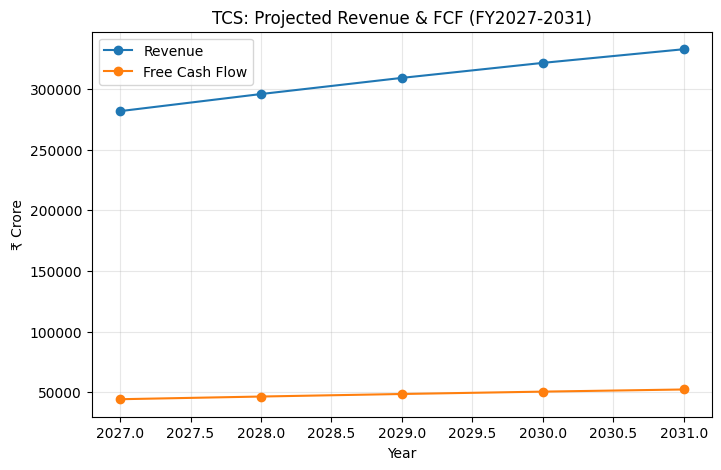

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_projection['Year'], df_projection['Revenue (₹ Cr)'], marker='o', label='Revenue')
plt.plot(df_projection['Year'], df_projection['FCF (₹ Cr)'], marker='o', label='Free Cash Flow')
plt.title('TCS: Projected Revenue & FCF (FY2027-2031)')
plt.xlabel('Year')
plt.ylabel('₹ Crore')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

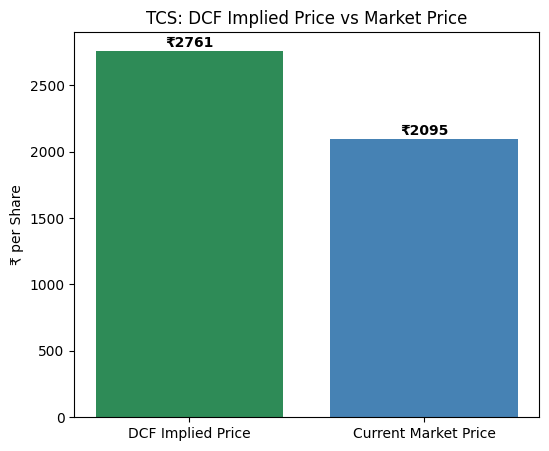

In [ ]:
plt.figure(figsize=(6,5))
bars = plt.bar(['DCF Implied Price', 'Current Market Price'],
                [price_per_share, current_price],
                color=['#2E8B57', '#4682B4'])

plt.title('TCS: DCF Implied Price vs Market Price')
plt.ylabel('₹ per Share')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 30, f'₹{height:.0f}',
              ha='center', fontweight='bold')

plt.show()